In [2]:
#Load packages
%matplotlib inline
import matplotlib as mpl
from matplotlib import pyplot as plt
import matplotlib.patheffects as path_effects
from matplotlib.collections import LineCollection
from matplotlib.patches import Rectangle,ConnectionPatch
from matplotlib.gridspec import GridSpec
import matplotlib.dates as mdates
import pandas as pd
typeface='Helvetica Neue'
mpl.rcParams['font.weight']=300
mpl.rcParams['axes.labelweight']=300
mpl.rcParams['font.family']=typeface
mpl.rcParams['font.size']=22
mpl.rcParams['pdf.fonttype']=42

import os,glob
import numpy as np
import baltic as bt
import json
import csv

def hpd(data, level): #Thanks Gytis Dudas for this
    """
    Return highest posterior density interval from a list,
    given the percent posterior density interval required.
    """
    d = list(data)
    d.sort()

    nData = len(data)
    nIn = int(round(level * nData))
    if nIn < 2 :
        return None
    #raise RuntimeError("Not enough data. N data: %s"%(len(data)))
 
    i = 0
    r = d[i+nIn-1] - d[i]
    for k in range(len(d) - (nIn - 1)) :
        rk = d[k+nIn-1] - d[k]
        if rk < r :
            r = rk
            i = k

    assert 0 <= i <= i+nIn-1 < len(d)
 
    return (d[i], d[i+nIn-1])

In [3]:
#TMRCA statistics

TMRCA = []

with open("/Users/ricardorivero/Documents/DENV/2024/D2/Logs/2024-09-25_D2_D2.aligned.log","r") as f:
    reader = csv.DictReader(f, delimiter="\t")
    print(reader.fieldnames)
    for row in reader:
        mrca = float(row['age(root)'])
        TMRCA.append(mrca)

TMRCA_data = pd.DataFrame(TMRCA,columns=['TMRCA'])
print(TMRCA_data)

['state', 'joint', 'prior', 'likelihood', 'treeModel.rootHeight', 'age(root)', 'treeLength', 'skyline.popSize1', 'skyline.popSize2', 'skyline.popSize3', 'skyline.popSize4', 'skyline.popSize5', 'skyline.popSize6', 'skyline.popSize7', 'skyline.popSize8', 'skyline.popSize9', 'skyline.popSize10', 'skyline.popSize11', 'skyline.popSize12', 'skyline.popSize13', 'skyline.popSize14', 'skyline.popSize15', 'skyline.popSize16', 'skyline.popSize17', 'skyline.popSize18', 'skyline.popSize19', 'skyline.popSize20', 'skyline.groupSize1', 'skyline.groupSize2', 'skyline.groupSize3', 'skyline.groupSize4', 'skyline.groupSize5', 'skyline.groupSize6', 'skyline.groupSize7', 'skyline.groupSize8', 'skyline.groupSize9', 'skyline.groupSize10', 'skyline.groupSize11', 'skyline.groupSize12', 'skyline.groupSize13', 'skyline.groupSize14', 'skyline.groupSize15', 'skyline.groupSize16', 'skyline.groupSize17', 'skyline.groupSize18', 'skyline.groupSize19', 'skyline.groupSize20', 'gtr.rates.rateAC', 'gtr.rates.rateAG', 'gtr.

In [4]:
print(TMRCA_data.describe())

               TMRCA
count  200001.000000
mean     2004.482092
std         6.791592
min      1835.072989
25%      2004.673482
50%      2005.340778
75%      2005.732240
max      2006.000000


(2000.0, 2009.0)

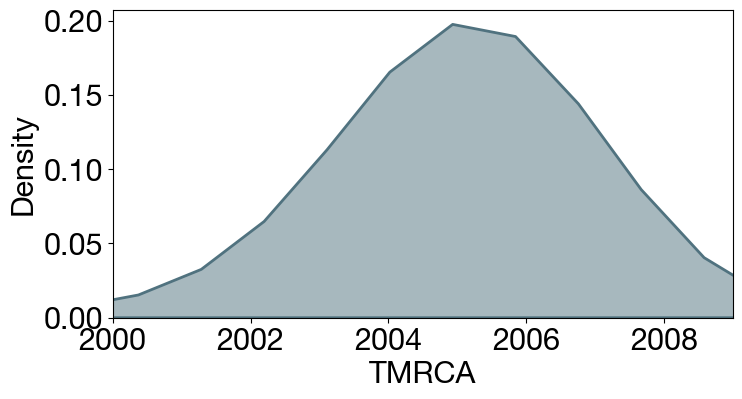

In [5]:
#Plot density plot with seaborn
#compute density
from scipy.stats import gaussian_kde
import seaborn as sns
from scipy.stats import norm

from sklearn.neighbors import KernelDensity


# Create the figure and axes
fig, ax = plt.subplots(figsize=(8, 4), facecolor='w', frameon=False)

# Plot the data
sns.kdeplot(ax, x=TMRCA_data['TMRCA'], color='#50727F', linewidth=2, fill=True, alpha=0.5, bw_adjust=3)
ax.set_xlim(2000, 2009)



In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import seaborn as sns

In [49]:
treePath = '/Users/ricardorivero/Documents/DENV/2024/D2/Trees/D2_lineage_combined.mcc.tre'

ll = bt.loadNexus(treePath, absoluteTime=True, sortBranches=True)

focal_node=ll.commonAncestor([k for k in ll.getExternal(lambda w: w.is_leaf())])

print(focal_node.y)

124.4416424036026


2005.2764601927336
['Ecuador', 'USA', 'Venezuela', 'Colombia', 'VAC', 'ARAUCA', 'CASANARE']


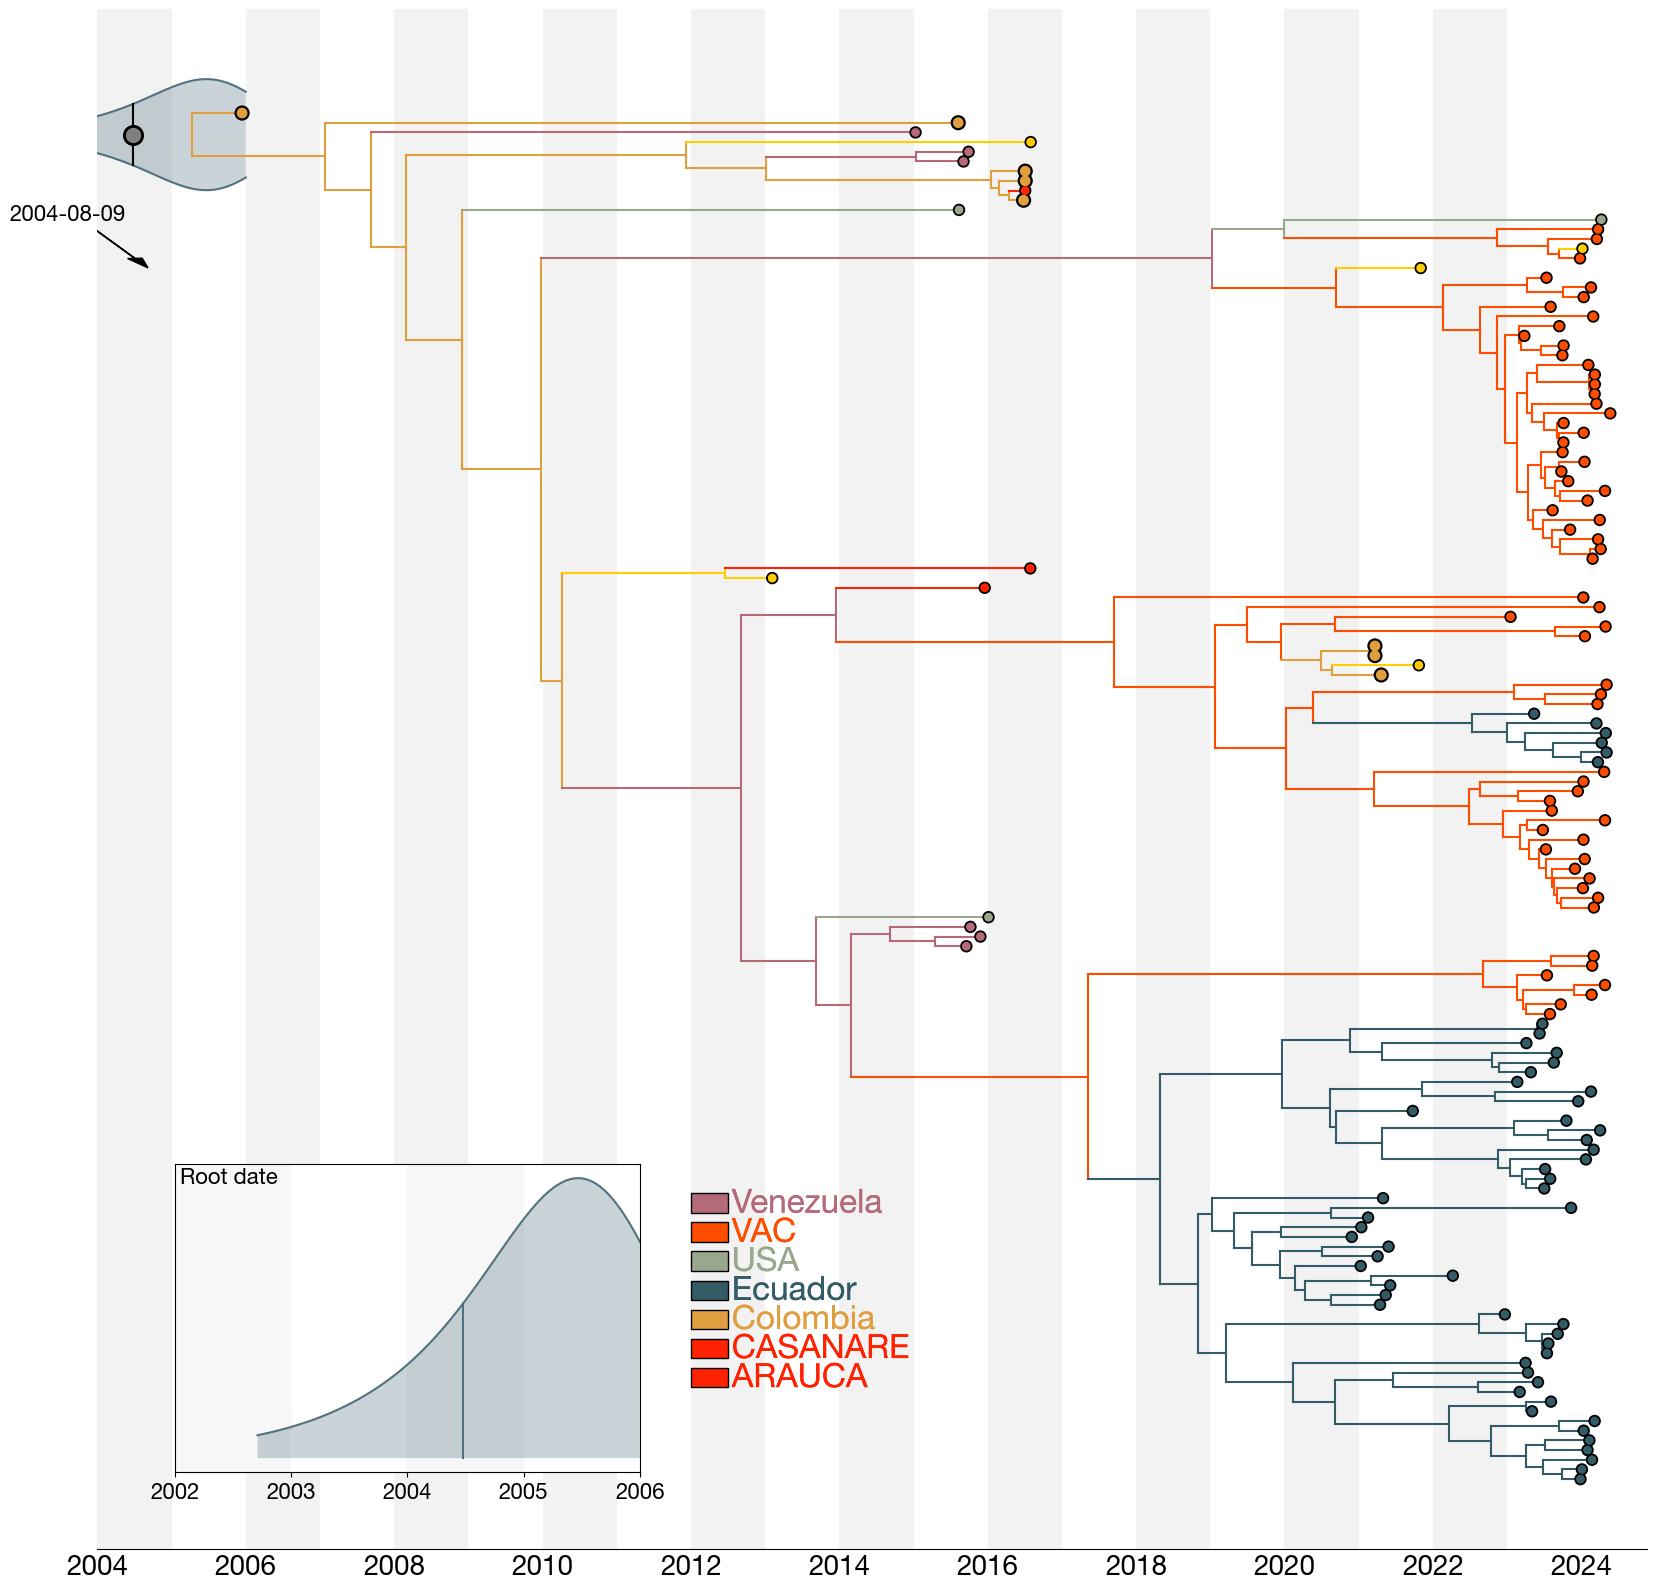

In [15]:
import matplotlib.patches as mpatches
treePath = '/Users/ricardorivero/Documents/DENV/2024/D2/Trees/DTA/2024-09-25_D2_D2_Markov.aligned.mcc.tree'

ll = bt.loadNexus(treePath, absoluteTime=True, sortBranches=True)
focal_node=ll.commonAncestor([k for k in ll.getExternal(lambda w: w.is_leaf())])
x_attr = lambda k: k.absoluteTime

colors = {'Ecuador':'#335c67', 'USA': '#99a88c', 'Venezuela': '#B56A7A', 'Colombia':'#e09f3e', 'VAC':'#ff4d00', 'ARAUCA': '#ff2200', 'CASANARE':'#ff2200'}



earliest_node = 100000000
for k in ll.Objects:
    if k.absoluteTime < earliest_node:
        earliest_node = k.absoluteTime

print(earliest_node)

root_y = 0
for k in ll.Objects:
    if k.absoluteTime == earliest_node:
        root_y = k.y

c_func = lambda k: colors[k.traits['location']] if 'location' in k.traits and k.traits['location'] in colors else '#FFCD00'
s_func = lambda k: 60 if k.traits['location'] == 'Colombia' else 40

fig, ax = plt.subplots(figsize=(20, 20), facecolor='w')
ll.plotTree(ax, x_attr=lambda k: k.absoluteTime, colour=c_func, width=1.5)
ll.plotPoints(ax, x_attr=lambda k: k.absoluteTime, colour=c_func, size=s_func, zorder=1000)

ax.text(2004.606-1, 124+6, '2004-08-09', fontsize=16, ha='center', va='bottom', color='k')
plt.arrow(2004.606-1, 124+7.5, 0.9, -5, 
          head_width = 0.2,
          head_length = 1,
          width = 0.01,
          ec ='k',
          fc = 'k', zorder = 1000)

data = TMRCA_data['TMRCA']
kde=gaussian_kde(data)
hpdLo,hpdHi=hpd(data,0.95)
x_grid=np.linspace(hpdLo,hpdHi,100)
scale=13
if focal_node.y is not None:
    y_up = [focal_node.y + y * scale for y in kde(x_grid)]
else:
    y_up = []
if focal_node.y is not None:
    y_lo=[focal_node.y - y * scale for y in kde(x_grid)]
else: 
    y_lo = []

ax.plot(x_grid,y_lo,color='#50727F') ## plot TMRCA 95% HPD
ax.plot(x_grid,y_up,color='#50727F')
ax.fill_between(x_grid,y_lo,y_up,facecolor='#50727F',alpha=0.3)
    
mu=np.mean(data) ## indicate mean
ax.plot([mu,mu],[focal_node.y+kde(mu)*scale,focal_node.y-kde(mu)*scale],ls='-',color='k')
ax.scatter(mu,focal_node.y,s=100,facecolor='grey',zorder=3)
ax.scatter(mu,focal_node.y,s=200,facecolor='k',zorder=2)
    
mostRecent=max(ll.getParameter('absoluteTime'))

years = np.arange(2004, 2025, 2)

axins = ax.inset_axes([0.05, 0.05, 0.3, 0.2]) ## inset axes for root TMRCA
    
node=ll.root
data=TMRCA_data['TMRCA'] ## get root TMRCA posterior
#annotate the date of the root
    
kde=gaussian_kde(data)
hpdLo,hpdHi=hpd(data,0.95)
x_grid=np.linspace(hpdLo,hpdHi,100)
y_grid=kde(x_grid)
    
    
axins.plot(x_grid,y_grid,color='#50727F') ## plot root TMRCA
axins.fill_between(x_grid,y_grid,facecolor='#50727F',alpha=0.3)
mu=np.mean(data)
mu_density = kde(mu)[0]
axins.plot([mu,mu],[0,mu_density],color='#50727F')
    

[axins.axvspan(t,t+1,facecolor='k',edgecolor='none',alpha=0.03,zorder=0) for t in range(2002,2006,1) if t % 2 == 0] 
    
axins.set_yticks([])
axins.set_yticklabels([])
axins.tick_params(labelsize=16)
axins.text(0.01,0.99,'Root date',size=16,va='top',ha='left',transform=axins.transAxes)
    
axins.set_xlim(2002,2006)


country_list = list(colors.keys())
print(country_list)

h=2
w=0.5

for c,C in enumerate(sorted(country_list)): ## add legend
    fc=colors[C] if C in colors else 'grey'
    effects=[path_effects.Stroke(linewidth=7, foreground='none'),
                        path_effects.Stroke(linewidth=0.0, foreground=fc)]
    ax.add_patch(Rectangle((2012,10+c*3),w,h,facecolor=fc,edgecolor='k',clip_on=False))
    ax.text(2012+w*1.1,10+c*3,C,size=24,color=fc,path_effects=effects)


# Set the x-ticks and labels to be the years array
plt.xticks(years, labels=[str(int(year)) for year in years])
[ax.spines[loc].set_visible(False) for loc in ax.spines if loc not in ['bottom']] ## remove all figure spines except bottom

ax.tick_params(axis='x',size=0,labelsize=20) ## no x axis ticks or labels
ax.tick_params(axis='y',size=0,labelsize=0) ## no y axis ticks or labels
ax.set_yticks([]) 
ax.set_yticklabels([])
[ax.axvspan(x,x+1,fc='k',ec='none',alpha=0.05,zorder=0) for x in range(2004,2024,1) if x%2==0]

ax.set_xlim(2004,ll.mostRecent+0.5)


resolutionValue = 1200
#plt.savefig('/Users/ricardorivero/Documents/DENV/2024/D2/Figures/TMRCA_D2.jpeg', dpi=resolutionValue, bbox_inches='tight')
plt.show()

2004.4654762302441
['Ecuador', 'USA', 'Venezuela', 'Colombia']


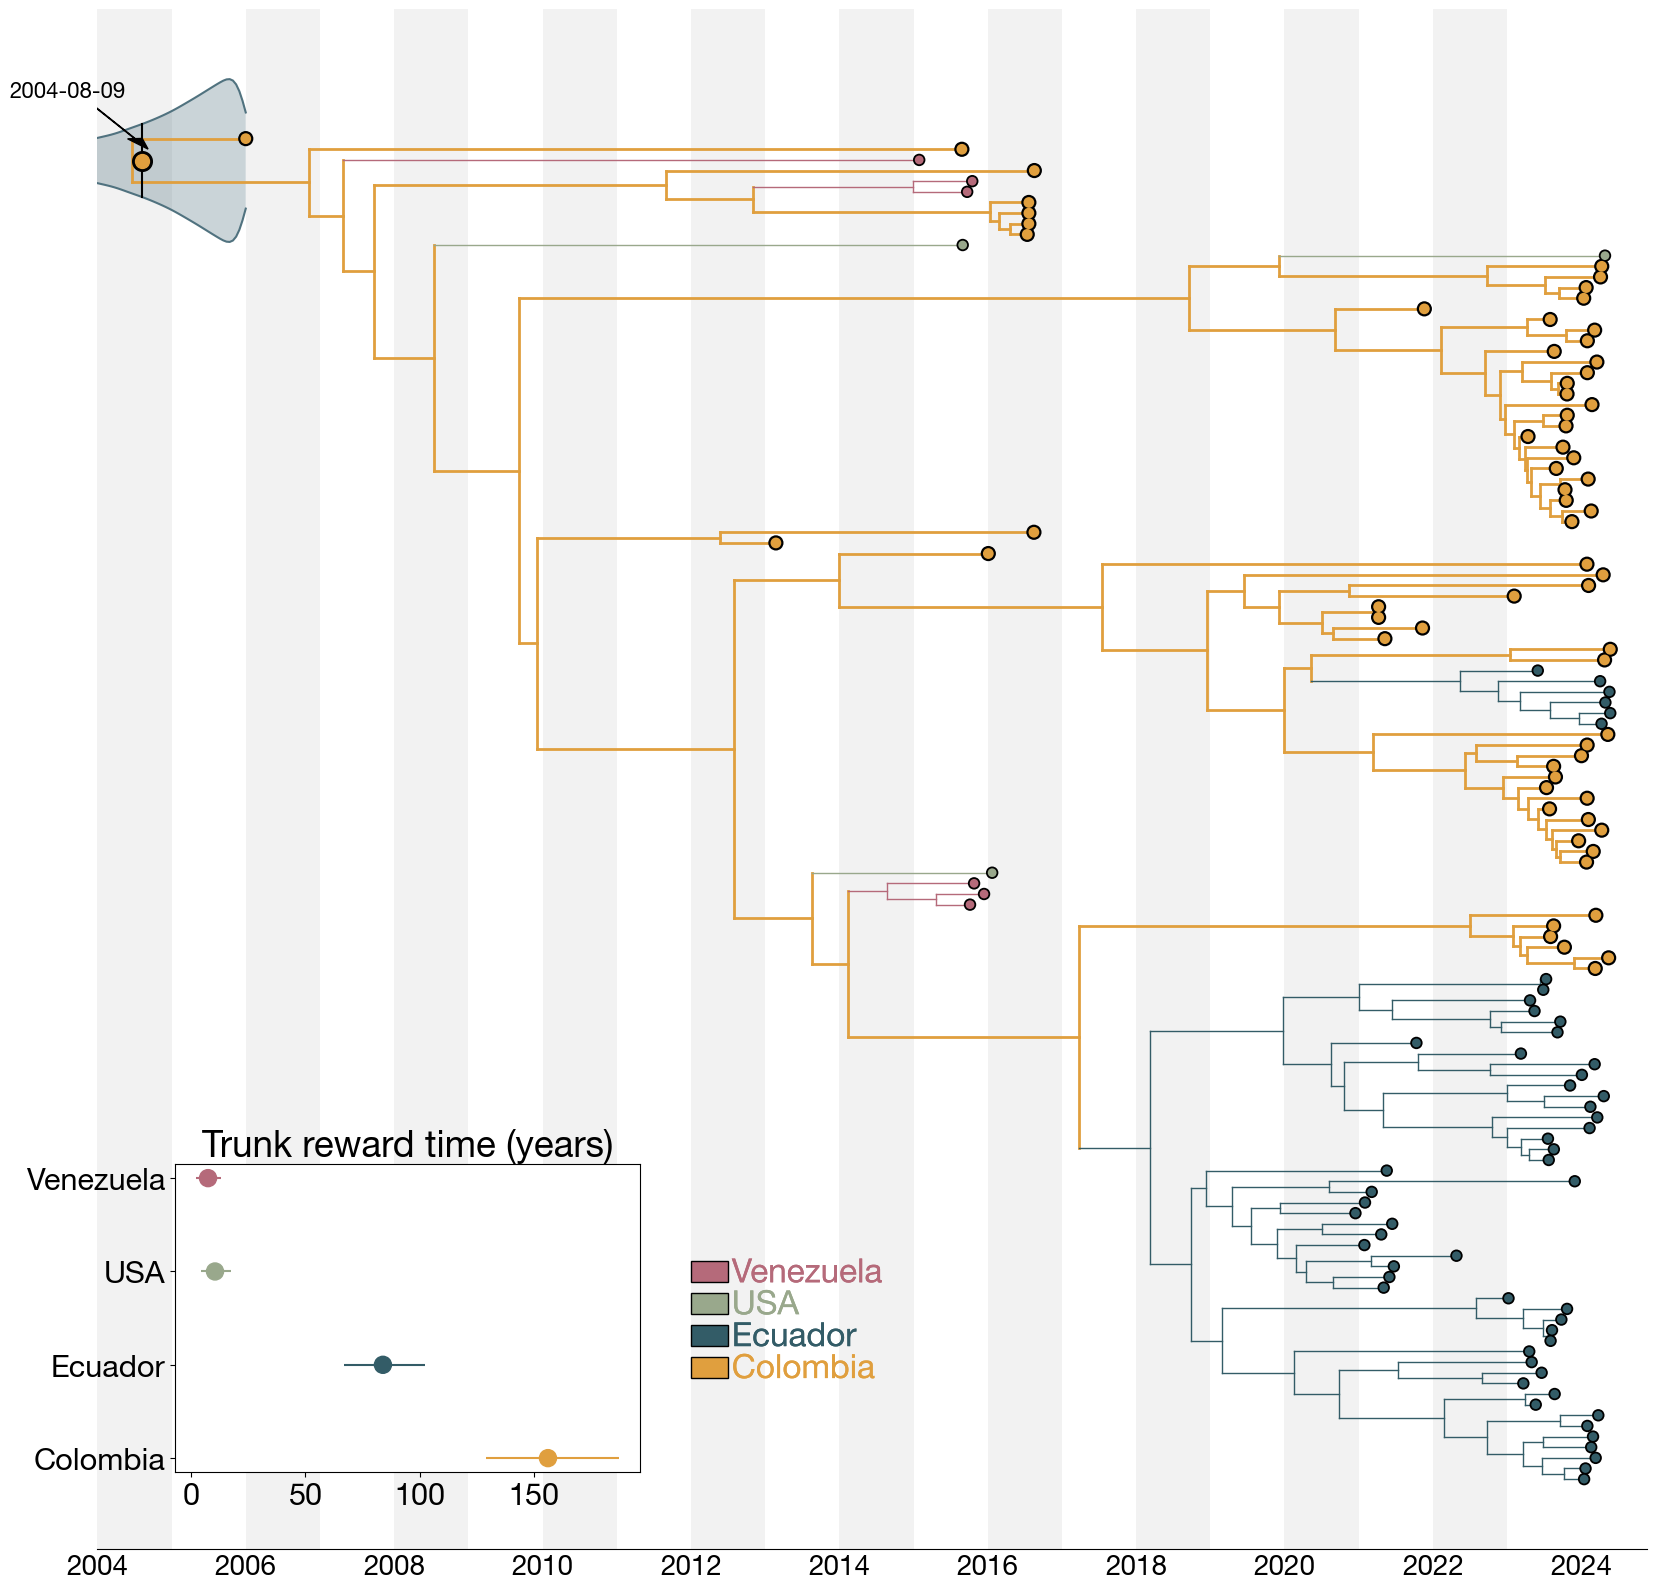

In [40]:
#Same analysis as above but including ancestral strate reconstruction
import matplotlib.patches as mpatches
import matplotlib.patches as mpatches
treePath = '/Users/ricardorivero/Documents/DENV/2024/D2/Trees/DTA/2024-09-25_D2_D2_Markov.aligned.mcc.tree'

ll = bt.loadNexus(treePath, absoluteTime=True, sortBranches=True)
focal_node=ll.commonAncestor([k for k in ll.getExternal(lambda w: w.is_leaf())])
x_attr = lambda k: k.absoluteTime

colors = {'Ecuador':'#335c67', 'USA': '#99a88c', 'Venezuela': '#B56A7A', 'Colombia':'#e09f3e'}


earliest_node = 100000000
for k in ll.Objects:
    if k.absoluteTime < earliest_node:
        earliest_node = k.absoluteTime

print(earliest_node)

root_y = 0
for k in ll.Objects:
    if k.absoluteTime == earliest_node:
        root_y = k.y

c_func = lambda k: colors[k.traits['location']] if 'location' in k.traits and k.traits['location'] in colors else '#FFCD00'
s_func = lambda k: 60 if k.traits['location'] == 'Colombia' else 40
line_func = lambda k: 2 if k.traits['location'] == 'Colombia' else 1

fig, ax = plt.subplots(figsize=(20, 20), facecolor='w')
ll.plotTree(ax, x_attr=lambda k: k.absoluteTime, colour=c_func, width=line_func)
ll.plotPoints(ax, x_attr=lambda k: k.absoluteTime, colour=c_func, size=s_func, zorder=1000)

ax.text(2004.606-1, 124+6, '2004-08-09', fontsize=16, ha='center', va='bottom', color='k')
plt.arrow(2004.606-1, 124+7.5, 0.9, -5, 
          head_width = 0.2,
          head_length = 1,
          width = 0.01,
          ec ='k',
          fc = 'k', zorder = 1000)

data = TMRCA_data['TMRCA']
kde=gaussian_kde(data)
hpdLo,hpdHi=hpd(data,0.95)
x_grid=np.linspace(hpdLo,hpdHi,100)
scale=13
if focal_node.y is not None:
    y_up = [focal_node.y + y * scale for y in kde(x_grid)]
else:
    y_up = []
if focal_node.y is not None:
    y_lo=[focal_node.y - y * scale for y in kde(x_grid)]
else: 
    y_lo = []

ax.plot(x_grid,y_lo,color='#50727F') ## plot TMRCA 95% HPD
ax.plot(x_grid,y_up,color='#50727F')
ax.fill_between(x_grid,y_lo,y_up,facecolor='#50727F',alpha=0.3)
    
mu=np.mean(data) ## indicate mean
ax.plot([mu,mu],[focal_node.y+kde(mu)*scale,focal_node.y-kde(mu)*scale],ls='-',color='k')
ax.scatter(mu,focal_node.y,s=100,facecolor='#e09f3e',zorder=3)
ax.scatter(mu,focal_node.y,s=200,facecolor='k',zorder=2)
    
mostRecent=max(ll.getParameter('absoluteTime'))

years = np.arange(2004, 2025, 2)


axins = ax.inset_axes([0.05, 0.05, 0.3, 0.2]) ## inset axes for root TMRCA

## Add trunk rewards inset

# Create dataframe
data = [{'state': 'Colombia', 'mean_reward': 156.238, 'HPD95Hi_reward': 187.2298, 'HPD95Lo_reward': 129.0948},
        {'state': 'Ecuador', 'mean_reward': 83.9406, 'HPD95Hi_reward': 102.4174, 'HPD95Lo_reward': 66.8716},
        {'state': 'USA', 'mean_reward': 10.3849, 'HPD95Hi_reward': 17.5269, 'HPD95Lo_reward': 4.3481},
        {'state': 'Venezuela', 'mean_reward': 7.33, 'HPD95Hi_reward': 13.1838, 'HPD95Lo_reward': 2.0552}]

trunkRewards = pd.DataFrame(data)

# Sort the dataframe by 'mean_reward' in descending order
trunkRewards = trunkRewards.sort_values(by='mean_reward', ascending=False).reset_index(drop=True)

# Plot trunk rewards
colors = {'Ecuador':'#335c67', 'USA': '#99a88c', 'Venezuela': '#B56A7A', 'Colombia':'#e09f3e'}

# Scatter plot for mean rewards, using index positions for y-axis
y_positions = range(len(trunkRewards))

axins.scatter(trunkRewards['mean_reward'], y_positions, s=150, color=[colors[state] for state in trunkRewards['state']], zorder=1000)

# Plot the HPD95 intervals using horizontal lines
axins.hlines(y=y_positions, xmin=trunkRewards['HPD95Lo_reward'], xmax=trunkRewards['HPD95Hi_reward'], color=[colors[state] for state in trunkRewards['state']], zorder=1000)

# Set the y-ticks to the state names
axins.set_yticks(y_positions)
axins.set_yticklabels(trunkRewards['state'])

axins.set_xlabel('')
axins.set_title('Trunk reward time (years)')

#node=ll.root
#data=TMRCA_data['TMRCA'] ## get root TMRCA posterior
#annotate the date of the root
    
#kde=gaussian_kde(data)
#hpdLo,hpdHi=hpd(data,0.95)
#x_grid=np.linspace(hpdLo,hpdHi,100)
#y_grid=kde(x_grid)
    
    
#axins.plot(x_grid,y_grid,color='#50727F') ## plot root TMRCA
#axins.fill_between(x_grid,y_grid,facecolor='#50727F',alpha=0.3)
#mu=np.mean(data)
#mu_density = kde(mu)[0]
#axins.plot([mu,mu],[0,mu_density],color='#50727F')
    

#axins.axvspan(t,t+1,facecolor='k',edgecolor='none',alpha=0.03,zorder=0) for t in range(2002,2006,1) if t % 2 == 0] 
    
#axins.set_yticks([])
#axins.set_yticklabels([])
#axins.tick_params(labelsize=16)
#axins.text(0.01,0.99,'Root date',size=16,va='top',ha='left',transform=axins.transAxes)
    
#axins.set_xlim(2002,2006)


country_list = list(colors.keys())
print(country_list)

h=2
w=0.5

for c,C in enumerate(sorted(country_list)): ## add legend
    fc=colors[C] if C in colors else 'grey'
    effects=[path_effects.Stroke(linewidth=7, foreground='none'),
                        path_effects.Stroke(linewidth=0.0, foreground=fc)]
    ax.add_patch(Rectangle((2012,10+c*3),w,h,facecolor=fc,edgecolor='k',clip_on=False))
    ax.text(2012+w*1.1,10+c*3,C,size=24,color=fc,path_effects=effects)


# Set the x-ticks and labels to be the years array
plt.xticks(years, labels=[str(int(year)) for year in years])
[ax.spines[loc].set_visible(False) for loc in ax.spines if loc not in ['bottom']] ## remove all figure spines except bottom

ax.tick_params(axis='x',size=0,labelsize=20) ## no x axis ticks or labels
ax.tick_params(axis='y',size=0,labelsize=0) ## no y axis ticks or labels
ax.set_yticks([]) 
ax.set_yticklabels([])
[ax.axvspan(x,x+1,fc='k',ec='none',alpha=0.05,zorder=0) for x in range(2004,2024,1) if x%2==0]

ax.set_xlim(2004,ll.mostRecent+0.5)


resolutionValue = 1200
plt.savefig('/Users/ricardorivero/Documents/DENV/2024/D2/Figures/DTA_D2.jpeg', dpi=resolutionValue, bbox_inches='tight')
plt.show()

{'Venezuela': [<baltic.baltic.tree object at 0x310d2c1d0>]}
{'Venezuela': [<baltic.baltic.tree object at 0x310d2c1d0>], 'USA': [<baltic.baltic.tree object at 0x3115b9410>]}
{'Venezuela': [<baltic.baltic.tree object at 0x310d2c1d0>], 'USA': [<baltic.baltic.tree object at 0x3115b9410>], 'Ecuador': [<baltic.baltic.tree object at 0x3114bb6d0>]}


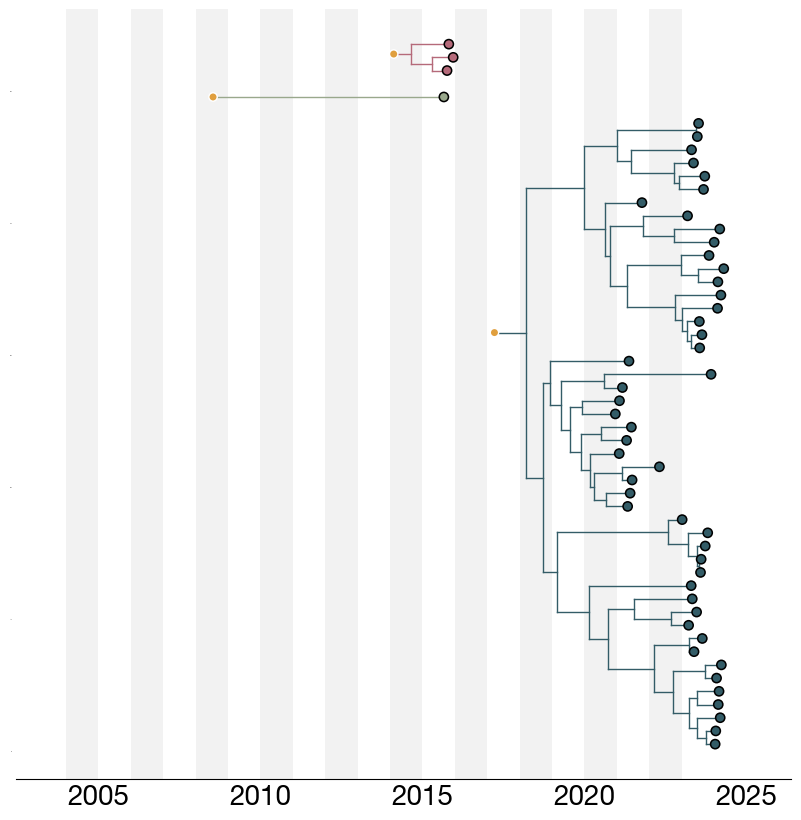

In [254]:
#Exploded tree to visualize introductions and state changes
from matplotlib.gridspec import GridSpec
from matplotlib import gridspec

country_colors = {'Ecuador':'#335c67', 'USA': '#99a88c', 'Venezuela': '#B56A7A', 'Colombia':'#e09f3e'}

c_func = lambda k: country_colors[k.traits['location']] if 'location' in k.traits and k.traits['location'] in country_colors else 'grey'

treePath = '/Users/ricardorivero/Documents/DENV/2024/D2/Trees/DTA/subsampled_D2lin_markov.aligned.mcc.tree'

ll = bt.loadNexus(treePath, absoluteTime=True, sortBranches=True)

fig = plt.figure(figsize=(10, 10),facecolor='w') ## create figure
gs = gridspec.GridSpec(1,1,wspace=0.0) ## using gridspec by default
ax=plt.subplot(gs[0],facecolor='w') ## create axes

location_is_colombia = lambda k: k.traits['location'] == 'Colombia'
location_colour = lambda k: '#e09f3e' if location_is_colombia(k) else country_colors[k.traits['location']] if 'location' in k.traits and k.traits['location'] in country_colors else 'grey'
location_color_colombia = lambda k: '#e09f3e' if location_is_colombia(k) else 'grey'

same_location = lambda k: 'location' in k.parent.traits and k.parent.traits['location'] == k.traits['location']

subtree_stack = {}


for k in sorted(ll.getBranches(lambda w: same_location(w) == False), key=lambda q: q.height):
    introduced_into = k.traits['location']
    if introduced_into not in subtree_stack and introduced_into != 'Colombia':
        subtree_stack[introduced_into] = []
        trait_subtree = ll.subtree(k, traverse_condition=same_location)
        subtree_stack[introduced_into].append(trait_subtree)
        print(subtree_stack)

cumulative_y_offset = 0
y_gap = 1

for trait in sorted(subtree_stack, key=lambda w: -subtree_stack[w][0].root.absoluteTime):
    for subtree in sorted(subtree_stack[trait], key=lambda w: -w.root.absoluteTime):
        subtree.drawTree()
        x_attr = lambda k: k.absoluteTime
        y_attr = lambda k: cumulative_y_offset + k.y * y_gap

        subtree.plotTree(ax, x_attr=x_attr, y_attr=y_attr, colour=location_colour, width=1)
        subtree.plotPoints(ax, x_attr=x_attr, y_attr=y_attr, colour=location_colour, size=30)

        origin_colour = location_colour(subtree.root.parent) if 'location' in subtree.root.parent.traits else 'grey'

        s=25
        ax.scatter(x_attr(subtree.root)-subtree.root.length, y_attr(subtree.root),s=s,facecolor=origin_colour,edgecolor='none', zorder=10)
        ax.scatter(x_attr(subtree.root)-subtree.root.length,y_attr(subtree.root),s=s*2,facecolor='w',edgecolor='none',zorder=9)

        cumulative_y_offset+=y_gap+subtree.ySpan

[ax.axvspan(x,x+1,fc='k',ec='none',alpha=0.05,zorder=0) for x in range(2004,2024,1) if x%2==0]

[ax.spines[loc].set_visible(False) for loc in ax.spines if loc not in ['bottom']] ## remove all figure spines except bottom

ax.tick_params(axis='x',size=0,labelsize=20) ## no x axis ticks or labels
ax.tick_params(axis='y',size=0,labelsize=0) ## no y axis ticks or labels

ax.set_xlim(ll.root.absoluteTime-2,ll.mostRecent+2) ## limit x axis

resolutionValue = 1200
plt.xlabel('')
#plt.savefig('/Users/ricardorivero/Documents/DENV/2024/phylogeography_D2_exploded.pdf', dpi=resolutionValue, bbox_inches='tight', format='pdf')
plt.show()


['Ecuador', 'USA', 'Venezuela', 'Colombia']


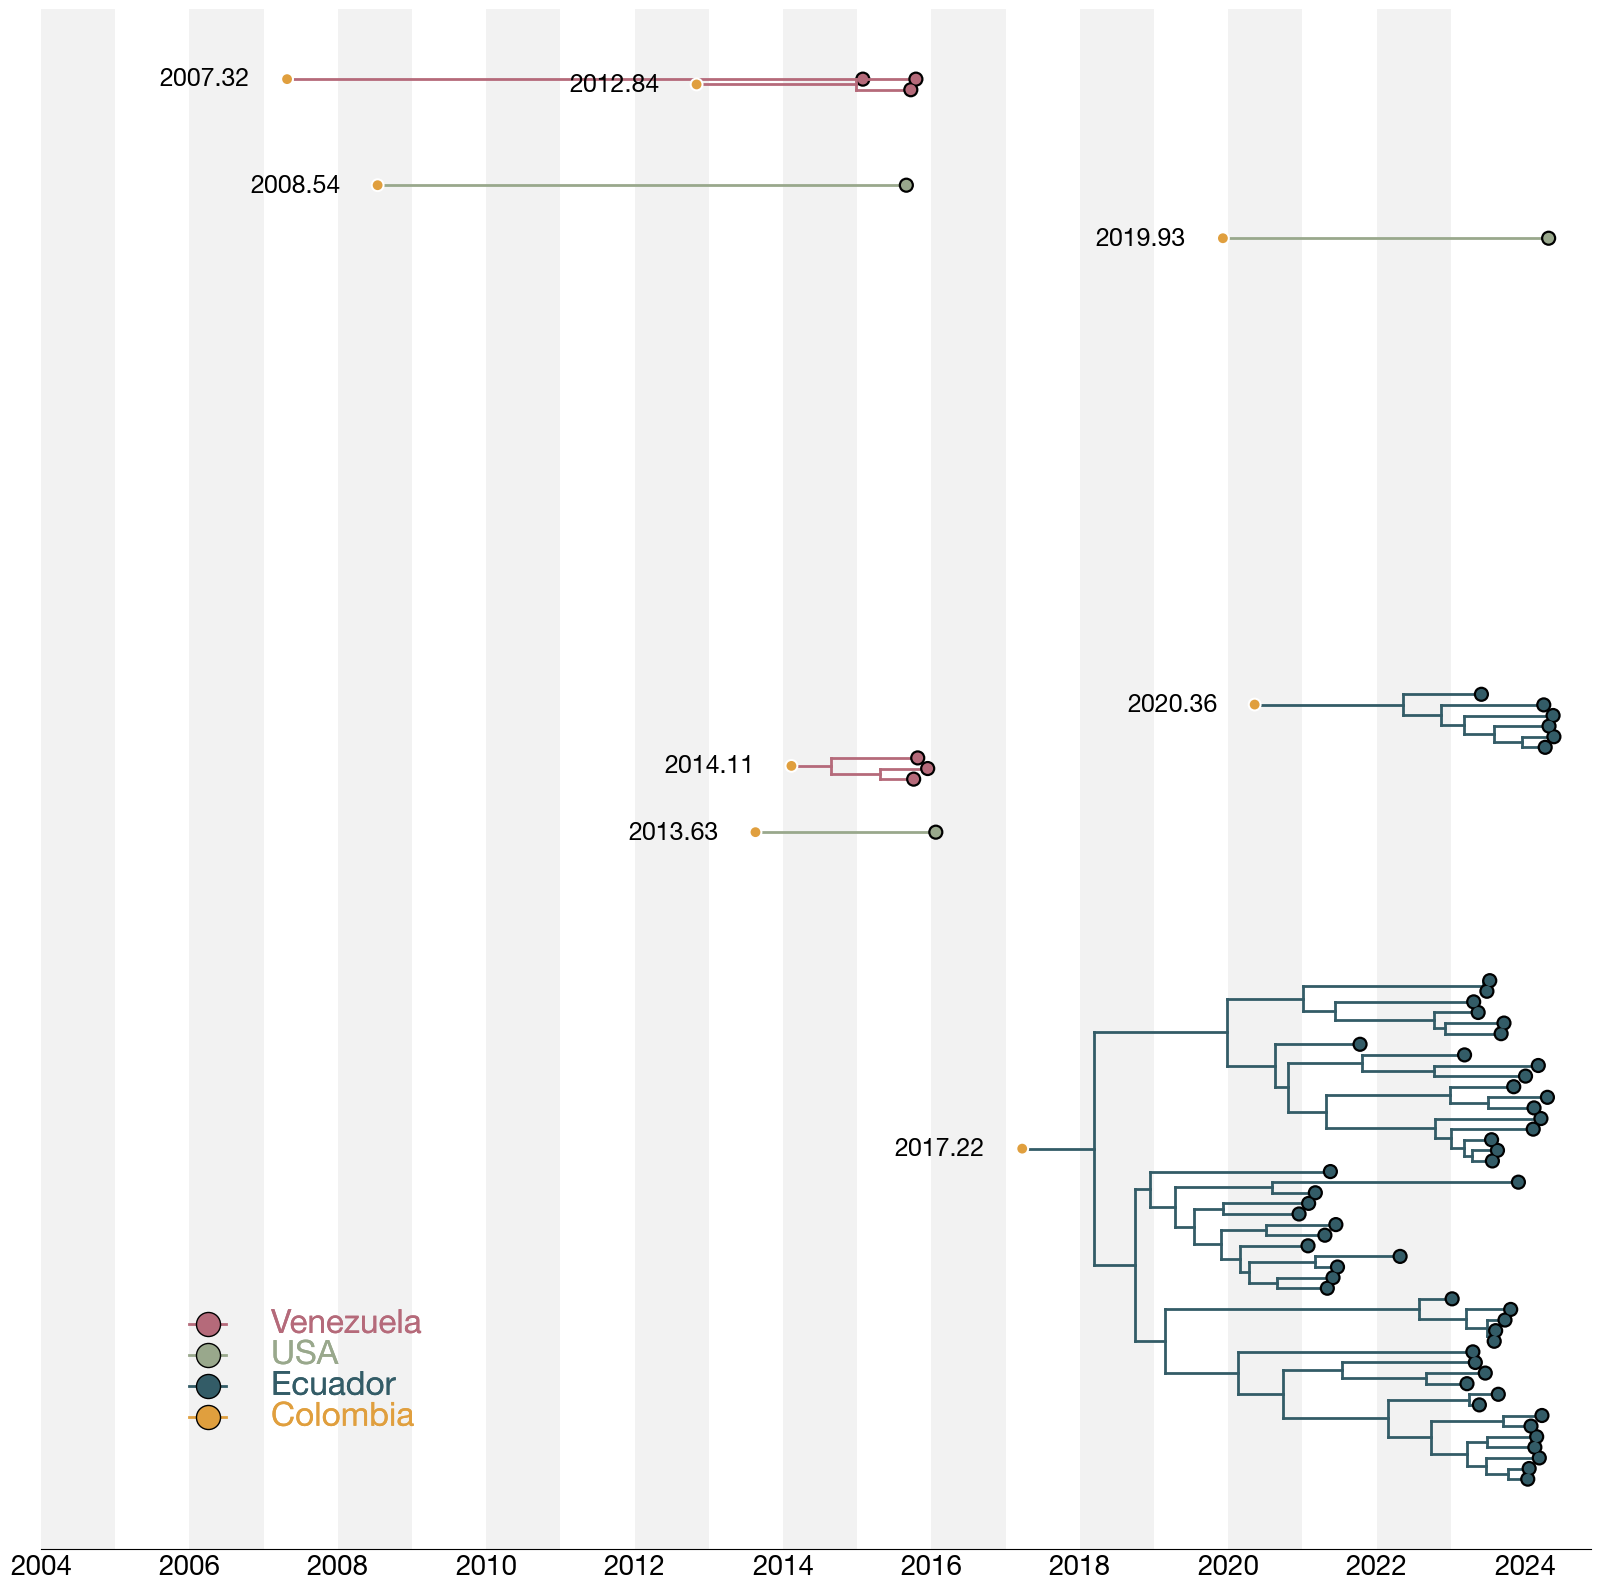

In [307]:
#Exploded tree to visualize introductions and state changes
from matplotlib.gridspec import GridSpec
from matplotlib import gridspec

country_colors = {'Ecuador':'#335c67', 'USA': '#99a88c', 'Venezuela': '#B56A7A', 'Colombia':'#e09f3e'}

c_func = lambda k: country_colors[k.traits['location']] if 'location' in k.traits and k.traits['location'] in country_colors else 'grey'

treePath = '/Users/ricardorivero/Documents/DENV/2024/D2/Trees/DTA/subsampled_D2lin_markov.aligned.mcc.tree'

ll = bt.loadNexus(treePath, absoluteTime=True, sortBranches=True)

fig = plt.figure(figsize=(20, 20), facecolor='w')  # create figure
gs = gridspec.GridSpec(1, 1, wspace=0.0)  # using gridspec by default
ax = plt.subplot(gs[0], facecolor='w')  # create axes

# Function to detect location changes
same_location = lambda k: 'location' in k.parent.traits and k.parent.traits['location'] != k.traits['location']

# Dictionary to store subtrees for each introduction state
subtree_stack = {}
subtree_tmrcas = {}  # Dictionary to store TMRCA for each subtree

# Collect subtrees for all states (not just Colombia)
for k in sorted(ll.getBranches(lambda w: same_location(w)), key=lambda q: q.height):
    introduced_into = k.traits['location']
    
    # If the state is not yet in the dictionary, initialize its list
    if introduced_into not in subtree_stack:
        subtree_stack[introduced_into] = []

    # Extract the subtree based on state change
    trait_subtree = ll.subtree(k, traverse_condition=lambda node: not same_location(node), stem=True)
    
    # Append the subtree to the corresponding state
    subtree_stack[introduced_into].append(trait_subtree)

    # Store the TMRCA for this subtree (root's absoluteTime)
    subtree_tmrcas[trait_subtree] = k.parent.absoluteTime  # Maps subtree to its TMRCA



# Start plotting the accumulated subtrees
cumulative_y_offset = 0
y_gap = 1.2

# Iterate over the stored subtrees by state
for trait in sorted(subtree_stack, key=lambda w: -subtree_stack[w][0].root.absoluteTime):
    for subtree in sorted(subtree_stack[trait], key=lambda w: -w.root.absoluteTime):
        x_attr = lambda k: k.absoluteTime
        y_attr = lambda k: cumulative_y_offset + k.y * y_gap

        # Plot the tree
        subtree.plotTree(ax, x_attr=x_attr, y_attr=y_attr, colour=c_func, width=2)
        subtree.plotPoints(ax, x_attr=x_attr, y_attr=y_attr, colour=c_func, size=60)

        # Plot the origin point with color
        origin_colour = c_func(subtree.root.parent) if 'location' in subtree.root.parent.traits else 'grey'
        s = 50
        ax.scatter(x_attr(subtree.root) - subtree.root.length, y_attr(subtree.root), s=s, facecolor=origin_colour, edgecolor='none', zorder=10)
        ax.scatter(x_attr(subtree.root) - subtree.root.length, y_attr(subtree.root), s=s * 2, facecolor='w', edgecolor='none', zorder=9)

        # Annotate TMRCA from the dictionary
        tmrca_value = subtree_tmrcas[subtree]  # Get the TMRCA value from the dictionary
        ax.text(x_attr(subtree.root) - subtree.root.length -0.5, y_attr(subtree.root), f'{tmrca_value:.2f}', 
                fontsize=18, ha='right', va='center', color='k')

        cumulative_y_offset += y_gap + subtree.ySpan  # Update the offset for the next subtree

        cumulative_y_offset += y_gap + subtree.ySpan  # Update the offset for the next subtree


country_list = list(colors.keys())
print(country_list)

h=2
w=0.5

for c, C in enumerate(sorted(country_list)):  ## add legend
    fc = colors[C] if C in colors else 'grey'
    effects = [path_effects.Stroke(linewidth=7, foreground='none'),
               path_effects.Stroke(linewidth=0.0, foreground=fc)]
    
    # Draw the line (from x = 2006 to x = 2007 with a y position based on c)
    ax.plot([2006, 2006.5], [10 + c * 3.5, 10 + c * 3.5], color=fc, lw=2)  # Line width set to 2

    # Add the big dot at the end of the line (x = 2007)
    ax.scatter(2006.25, 10 + c * 3.5, color=fc, s=300, edgecolor='k', zorder=10)  # s=100 controls the dot size

    # Add the text next to the dot
    ax.text(2007 + 0.1, 10 + c * 3.5, C, size=24, color=fc, path_effects=effects, va='center')
# Add background grid
[ax.axvspan(x, x + 1, fc='k', ec='none', alpha=0.05, zorder=0) for x in range(2004, 2024, 1) if x % 2 == 0]

# Remove all figure spines except bottom
years = np.arange(2004, 2025, 2)
plt.xticks(years, labels=[str(int(year)) for year in years])
[ax.spines[loc].set_visible(False) for loc in ax.spines if loc not in ['bottom']]

# No x-axis ticks or labels
ax.tick_params(axis='x', size=0, labelsize=20)
ax.tick_params(axis='y', size=0, labelsize=0)
ax.set_yticks([]) 
ax.set_yticklabels([])

# Limit x-axis range
ax.set_xlim(2004,ll.mostRecent+0.5)

resolutionValue = 1200
plt.xlabel('')
plt.savefig('/Users/ricardorivero/Documents/DENV/2024/D2/Figures/phylogeography_D2_exploded.jpeg', dpi=resolutionValue, bbox_inches='tight', format='jpeg')
plt.show()

In [6]:
#Analysis for the F.1.1.2 Lineage
#TMRCA statistics

TMRCA = []

with open("/Users/ricardorivero/Documents/DENV/2024/D2/Logs/subsampled_F112_combined.log","r") as f:
    reader = csv.DictReader(f, delimiter="\t")
    print(reader.fieldnames)
    for row in reader:
        mrca = float(row['age(root)'])
        TMRCA.append(mrca)

TMRCA_data = pd.DataFrame(TMRCA,columns=['TMRCA'])
print(TMRCA_data)


['state', 'joint', 'prior', 'likelihood', 'treeModel.rootHeight', 'age(root)', 'treeLength', 'skyline.popSize1', 'skyline.popSize2', 'skyline.popSize3', 'skyline.popSize4', 'skyline.popSize5', 'skyline.popSize6', 'skyline.popSize7', 'skyline.popSize8', 'skyline.popSize9', 'skyline.popSize10', 'skyline.groupSize1', 'skyline.groupSize2', 'skyline.groupSize3', 'skyline.groupSize4', 'skyline.groupSize5', 'skyline.groupSize6', 'skyline.groupSize7', 'skyline.groupSize8', 'skyline.groupSize9', 'skyline.groupSize10', 'gtr.rates.rateAC', 'gtr.rates.rateAG', 'gtr.rates.rateAT', 'gtr.rates.rateCG', 'gtr.rates.rateCT', 'gtr.rates.rateGT', 'frequencies1', 'frequencies2', 'frequencies3', 'frequencies4', 'alpha', 'ucld.mean', 'ucld.stdev', 'meanRate', 'coefficientOfVariation', 'covariance', 'treeLikelihood', 'branchRates', 'skyline']
              TMRCA
0       2018.261599
1       2018.246632
2       2018.618744
3       2018.120127
4       2018.124760
...             ...
539998  2018.733082
539999  2

(2014.0, 2020.0)

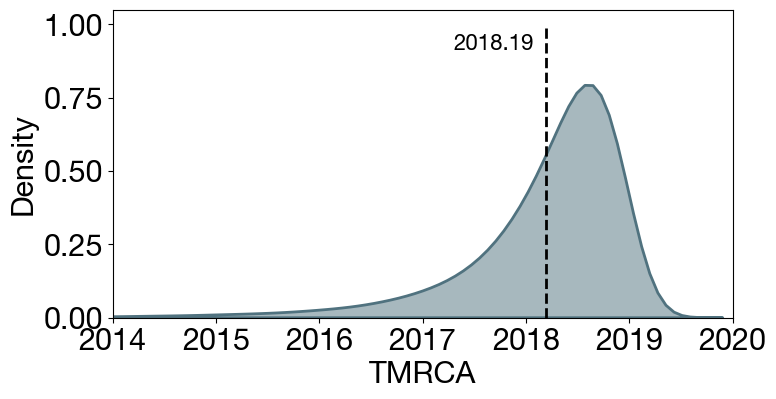

In [7]:
#Plot density plot with seaborn
#compute density
from scipy.stats import gaussian_kde
import seaborn as sns
from scipy.stats import norm

from sklearn.neighbors import KernelDensity


# Create the figure and axes
fig, ax = plt.subplots(figsize=(8, 4), facecolor='w', frameon=False)

# Plot the data
sns.kdeplot(ax, x=TMRCA_data['TMRCA'], color='#50727F', linewidth=2, fill=True, alpha=0.5, bw_adjust=3)
plt.vlines(x=np.mean(TMRCA_data['TMRCA']),ymin=0, ymax=1,  color='black', linestyle='--', lw=2)
plt.text(x=np.mean(TMRCA_data['TMRCA'])-0.5,y=0.9, s=np.round(np.mean(TMRCA_data['TMRCA']), decimals=2), ha='center', va='bottom', fontsize=16, color='black')
ax.set_xlim(2014, 2020)



2018.4094625714758
['Bolivia', 'Brazil', 'Colombia', 'The Caribbean', 'Ecuador', 'Central America', 'Mexico', 'Paraguay', 'Peru', 'United States', 'Bangladesh']


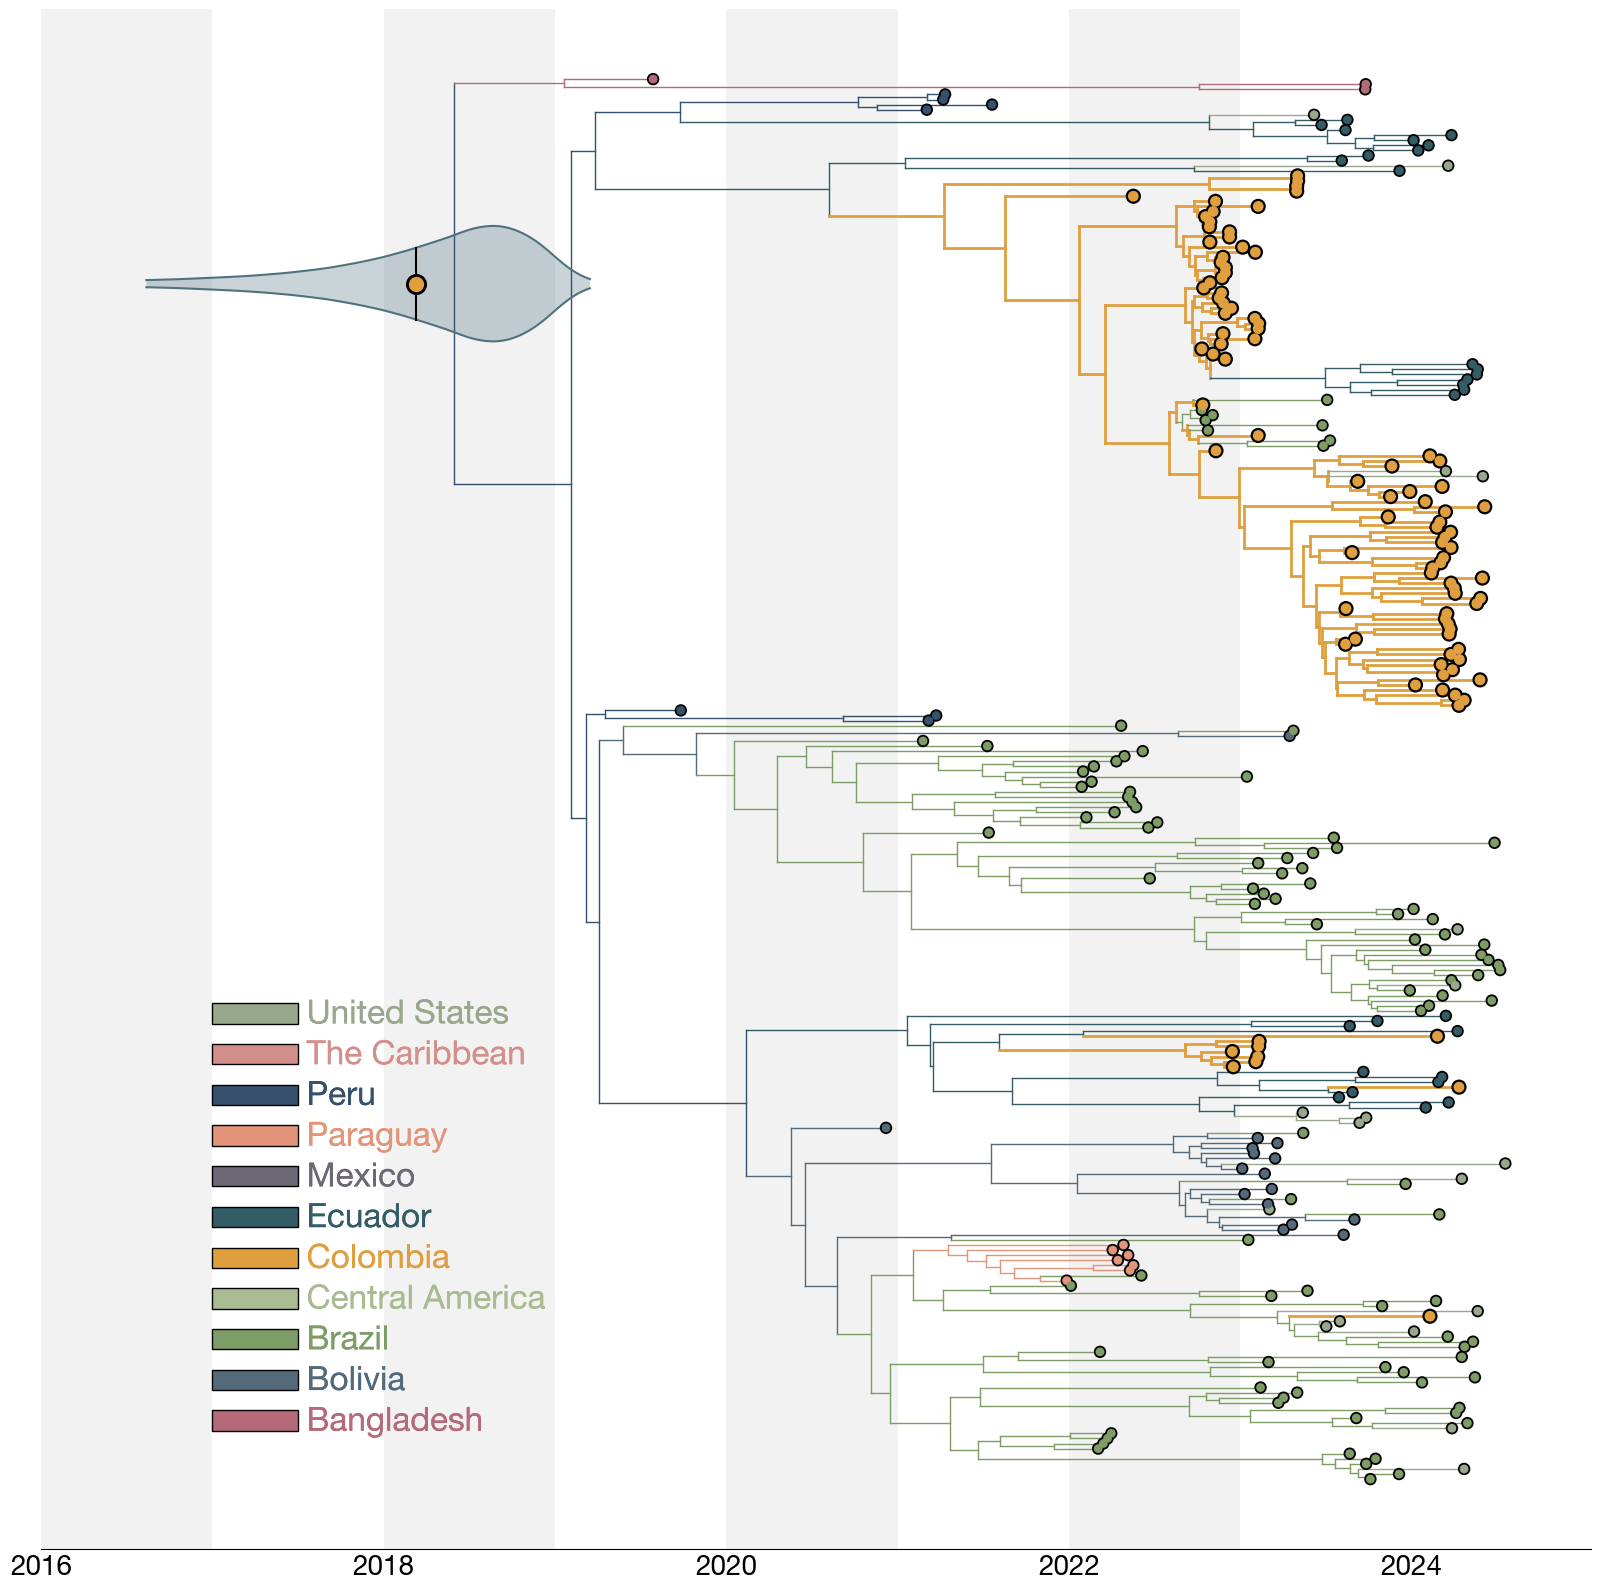

In [14]:
#Same analysis as above but including ancestral strate reconstruction
import matplotlib.patches as mpatches
import matplotlib.patches as mpatches
treePath = '/Users/ricardorivero/Documents/DENV/2024/D2/Trees/DTA/subsampled_F112_markov.aligned.mcc.tree'

ll = bt.loadNexus(treePath, absoluteTime=True, sortBranches=True)
focal_node=ll.commonAncestor([k for k in ll.getExternal(lambda w: w.is_leaf())])
x_attr = lambda k: k.absoluteTime

for k in ll.Objects:
    if k.traits['location'] == 'Central_America':
        k.traits['location'] = 'Central America'
    elif k.traits['location'] == 'Caribbean':
        k.traits['location'] = 'The Caribbean'
    elif k.traits['location'] == 'USA':
        k.traits['location'] = 'United States'

colors = {
    "Bolivia": "#546a7b",  # Slightly muted, keeping it.
    "Brazil": "#7e9c66",   # Changed to make it lighter and distinct.
    "Colombia": "#e09f3e", # Keeping this vibrant color.
    "The Caribbean": "#d38f8b", # Muted but distinguishable.
    "Ecuador": "#335c67",  # Dark and rich.
    "Central America": "#a9bb91", # Lightened to make it more distinguishable.
    "Mexico": "#6d6875",  # Slightly muted purple-gray.
    "Paraguay": "#e29578", # Keeping the warm tone.
    "Peru": "#36516D",    # Keeping the navy blue.
    "United States": "#99a88c",      # Light, keeping this.
    "Bangladesh": "#B56A7A" # Keeping the muted red.
}

labels = {
    "Bolivia": "Bolivia",
    "Brazil": "Brazil",
    "Colombia": "Colombia",
    "Caribbean": "The Caribbean",
    "Ecuador": "Ecuador",
    "Central_America": "Central America",
    "Mexico": "Mexico",
    "Paraguay": "Paraguay",
    "Peru": "Peru",
    "USA": "United States",
    "Bangladesh": "Bangladesh"
}


earliest_node = 100000000
for k in ll.Objects:
    if k.absoluteTime < earliest_node:
        earliest_node = k.absoluteTime

print(earliest_node)

root_y = 0
for k in ll.Objects:
    if k.absoluteTime == earliest_node:
        root_y = k.y

c_func = lambda k: colors[k.traits['location']] if 'location' in k.traits and k.traits['location'] in colors else '#FFCD00'
s_func = lambda k: 60 if k.traits['location'] == 'Colombia' else 40
line_func = lambda k: 2 if k.traits['location'] == 'Colombia' else 1

fig, ax = plt.subplots(figsize=(20, 20), facecolor='w')
ll.plotTree(ax, x_attr=lambda k: k.absoluteTime, colour=c_func, width=line_func)
ll.plotPoints(ax, x_attr=lambda k: k.absoluteTime, colour=c_func, size=s_func, zorder=1000)

#ax.text(2004.606-1, 124+6, '2004-08-09', fontsize=16, ha='center', va='bottom', color='k')
#plt.arrow(2004.606-1, 124+7.5, 0.9, -5, 
##          head_width = 0.2,
#         head_length = 1,
#          width = 0.01,
#          ec ='k',
#          fc = 'k', zorder = 1000)

data = TMRCA_data['TMRCA']
kde=gaussian_kde(data)
hpdLo,hpdHi=hpd(data,0.95)
x_grid=np.linspace(hpdLo,hpdHi,100)
scale=13
if focal_node.y is not None:
    y_up = [focal_node.y + y * scale for y in kde(x_grid)]
else:
    y_up = []
if focal_node.y is not None:
    y_lo=[focal_node.y - y * scale for y in kde(x_grid)]
else: 
    y_lo = []

ax.plot(x_grid,y_lo,color='#50727F') ## plot TMRCA 95% HPD
ax.plot(x_grid,y_up,color='#50727F')
ax.fill_between(x_grid,y_lo,y_up,facecolor='#50727F',alpha=0.3)
    
mu=np.mean(data) ## indicate mean
ax.plot([mu,mu],[focal_node.y+kde(mu)*scale,focal_node.y-kde(mu)*scale],ls='-',color='k')
ax.scatter(mu,focal_node.y,s=100,facecolor='#e09f3e',zorder=3)
ax.scatter(mu,focal_node.y,s=200,facecolor='k',zorder=2)
    
mostRecent=max(ll.getParameter('absoluteTime'))

years = np.arange(2004, 2025, 2)


#axins = ax.inset_axes([0.05, 0.05, 0.3, 0.2]) ## inset axes for root TMRCA

## Add trunk rewards inset

# Create dataframe
#data = [{'state': 'Colombia', 'mean_reward': 156.238, 'HPD95Hi_reward': 187.2298, 'HPD95Lo_reward': 129.0948},
#        {'state': 'Ecuador', 'mean_reward': 83.9406, 'HPD95Hi_reward': 102.4174, 'HPD95Lo_reward': 66.8716},
#        {'state': 'USA', 'mean_reward': 10.3849, 'HPD95Hi_reward': 17.5269, 'HPD95Lo_reward': 4.3481},
#        {'state': 'Venezuela', 'mean_reward': 7.33, 'HPD95Hi_reward': 13.1838, 'HPD95Lo_reward': 2.0552}]

#trunkRewards = pd.DataFrame(data)

# Sort the dataframe by 'mean_reward' in descending order
#trunkRewards = trunkRewards.sort_values(by='mean_reward', ascending=False).reset_index(drop=True)

# Plot trunk rewards
#colors = {'Ecuador':'#335c67', 'USA': '#99a88c', 'Venezuela': '#B56A7A', 'Colombia':'#e09f3e'}

# Scatter plot for mean rewards, using index positions for y-axis
#y_positions = range(len(trunkRewards))

#axins.scatter(trunkRewards['mean_reward'], y_positions, s=150, color=[colors[state] for state in trunkRewards['state']], zorder=1000)

# Plot the HPD95 intervals using horizontal lines
#axins.hlines(y=y_positions, xmin=trunkRewards['HPD95Lo_reward'], xmax=trunkRewards['HPD95Hi_reward'], color=[colors[state] for state in trunkRewards['state']], zorder=1000)

# Set the y-ticks to the state names
#axins.set_yticks(y_positions)
#axins.set_yticklabels(trunkRewards['state'])

#axins.set_xlabel('')
#axins.set_title('Trunk reward time (years)')

#node=ll.root
#data=TMRCA_data['TMRCA'] ## get root TMRCA posterior
#annotate the date of the root
    
#kde=gaussian_kde(data)
#hpdLo,hpdHi=hpd(data,0.95)
#x_grid=np.linspace(hpdLo,hpdHi,100)
#y_grid=kde(x_grid)
    
    
#axins.plot(x_grid,y_grid,color='#50727F') ## plot root TMRCA
#axins.fill_between(x_grid,y_grid,facecolor='#50727F',alpha=0.3)
#mu=np.mean(data)
#mu_density = kde(mu)[0]
#axins.plot([mu,mu],[0,mu_density],color='#50727F')
    

#axins.axvspan(t,t+1,facecolor='k',edgecolor='none',alpha=0.03,zorder=0) for t in range(2002,2006,1) if t % 2 == 0] 
    
#axins.set_yticks([])
#axins.set_yticklabels([])
#axins.tick_params(labelsize=16)
#axins.text(0.01,0.99,'Root date',size=16,va='top',ha='left',transform=axins.transAxes)
    
#axins.set_xlim(2002,2006)


country_list = list(colors.keys())
print(country_list)

h=4
w=0.5

for c,C in enumerate(sorted(country_list)): ## add legend
    fc=colors[C] if C in colors else 'grey'
    effects=[path_effects.Stroke(linewidth=7, foreground='none'),
                        path_effects.Stroke(linewidth=0.0, foreground=fc)]
    ax.add_patch(Rectangle((2017,10+c*8),w,h,facecolor=fc,edgecolor='k',clip_on=False))
    ax.text(2017+w*1.1,10+c*8,C,size=24,color=fc,path_effects=effects)


# Set the x-ticks and labels to be the years array
plt.xticks(years, labels=[str(int(year)) for year in years])
[ax.spines[loc].set_visible(False) for loc in ax.spines if loc not in ['bottom']] ## remove all figure spines except bottom

ax.tick_params(axis='x',size=0,labelsize=20) ## no x axis ticks or labels
ax.tick_params(axis='y',size=0,labelsize=0) ## no y axis ticks or labels
ax.set_yticks([]) 
ax.set_yticklabels([])
[ax.axvspan(x,x+1,fc='k',ec='none',alpha=0.05,zorder=0) for x in range(2004,2024,1) if x%2==0]

ax.set_xlim(2016,ll.mostRecent+0.5)


resolutionValue = 1200
#plt.savefig('/Users/ricardorivero/Documents/DENV/2024/D2/Figures/DTA_F112.jpeg', dpi=resolutionValue, bbox_inches='tight')
plt.show()